<a href="https://colab.research.google.com/github/simsekergun/WGeffectiveIndex/blob/main/WG_neff_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# ML models
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
# Multilayer Perceptron
from keras.models import Model
from keras.layers import Input
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import concatenate
from tensorflow.keras import optimizers
from tensorflow.keras import backend
from keras.layers import LeakyReLU, PReLU

In [4]:
df1 = pd.read_csv('https://raw.githubusercontent.com/simsekergun/WGeffectiveIndex/refs/heads/main/training_dataset.csv')
df2 = pd.read_csv('https://raw.githubusercontent.com/simsekergun/WGeffectiveIndex/refs/heads/main/testing_dataset.csv')

In [5]:
df1.head(4)

,lambda_um,width_um,height_um,n_eff_TE,n_eff_TM
0,0.75,0.75,0.600,1.917738,1.911493
1,0.75,0.75,0.625,1.921459,1.916615
2,0.75,0.75,0.650,1.924864,1.921229
3,0.75,0.75,0.675,1.927961,1.925414


In [6]:
df2.head(4)

,lambda_um,width_um,height_um,n_eff_TE,n_eff_TM
0,0.750103,0.770541,0.615622,1.922480,1.916546
1,0.750103,0.770541,0.634018,1.925085,1.920133
2,0.750103,0.770541,0.667932,1.929486,1.926060
3,0.750103,0.770541,0.725370,1.935810,1.934491


In [8]:
df1.shape, df2.shape

((19499, 5), (1000, 5))

## Linear Regression

In [9]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Assuming df1 and df2 are already loaded with columns:
# lambda_um, width_um, height_um, n_eff_TE, n_eff_TM

feature_cols = ['lambda_um', 'width_um', 'height_um']
target_col = 'n_eff_TE'   # switch to 'n_eff_TM' if needed

X_train = df1[feature_cols].values
y_train = df1[target_col].values

X_test = df2[feature_cols].values
y_test = df2[target_col].values

# Fit linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"Test RMSE: {rmse:.6e}")
print(f"Test R^2: {r2:.6f}")

Coefficients: [-0.22027274  0.09975204  0.14380599]
Intercept: 1.8992658821589445
Test RMSE: 8.328002e-03
Test R^2: 0.971049


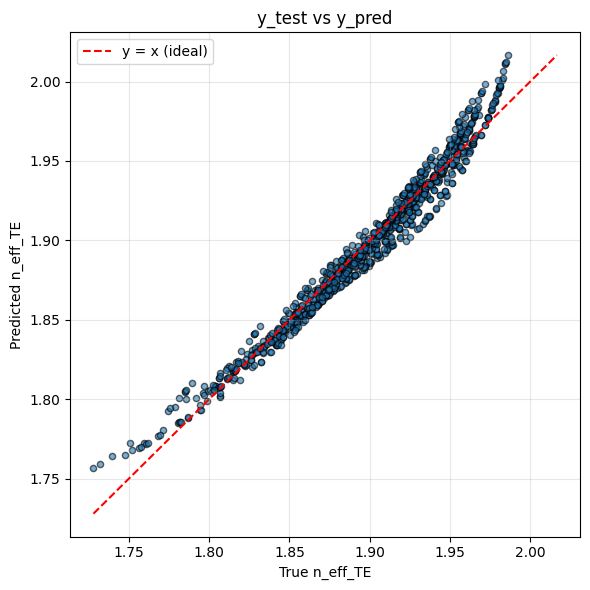

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', s=20)

# Add y = x reference line (perfect prediction)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x (ideal)')

plt.xlabel('True n_eff_TE')
plt.ylabel('Predicted n_eff_TE')
plt.title('y_test vs y_pred')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Fully connected neural network

Epoch 0: train_loss=1.013781e+00, val_loss=1.017992e+00
Epoch 200: train_loss=6.883481e-04, val_loss=6.655527e-04
Epoch 400: train_loss=1.320214e-04, val_loss=1.370228e-04
Epoch 600: train_loss=8.766282e-05, val_loss=9.129624e-05
Epoch 800: train_loss=7.055096e-05, val_loss=7.437164e-05
Epoch 1000: train_loss=5.767689e-05, val_loss=6.022227e-05
Epoch 1200: train_loss=5.014795e-05, val_loss=5.089503e-05
Epoch 1400: train_loss=4.451456e-05, val_loss=4.495931e-05
Epoch 1600: train_loss=5.573433e-05, val_loss=5.619492e-05
Epoch 1800: train_loss=4.675810e-05, val_loss=4.092839e-05
Epoch 2000: train_loss=3.264779e-05, val_loss=3.429530e-05
Epoch 2200: train_loss=3.434679e-05, val_loss=4.701219e-05
Epoch 2400: train_loss=2.578811e-05, val_loss=2.667747e-05
Epoch 2600: train_loss=3.273854e-05, val_loss=3.717307e-05
Epoch 2800: train_loss=2.275998e-05, val_loss=2.260257e-05

Test RMSE: 2.924107e-04
Test R^2: 0.999964


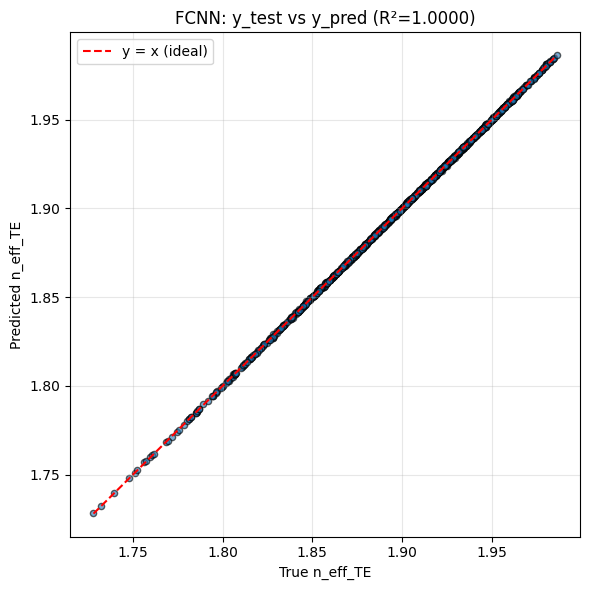

In [12]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ---------------------------
# Data prep
# ---------------------------
feature_cols = ['lambda_um', 'width_um', 'height_um']
target_col = 'n_eff_TE'

X_train = df1[feature_cols].values.astype(np.float32)
y_train = df1[target_col].values.astype(np.float32).reshape(-1, 1)

X_test = df2[feature_cols].values.astype(np.float32)
y_test = df2[target_col].values.astype(np.float32).reshape(-1, 1)

# Scale inputs (important: NN trains much better on normalized features)
x_scaler = StandardScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_test_s = x_scaler.transform(X_test)

# Scale target too (n_eff values are ~1-3, but scaling still helps convergence)
y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train)
y_test_s = y_scaler.transform(y_test)

X_train_t = torch.from_numpy(X_train_s)
y_train_t = torch.from_numpy(y_train_s)
X_test_t = torch.from_numpy(X_test_s)
y_test_t = torch.from_numpy(y_test_s)

# ---------------------------
# Model
# ---------------------------
class FCNN(nn.Module):
    def __init__(self, in_dim=3, hidden=(64, 64, 32), out_dim=1):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FCNN().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=200)

X_train_t, y_train_t = X_train_t.to(device), y_train_t.to(device)
X_test_t, y_test_t = X_test_t.to(device), y_test_t.to(device)

# ---------------------------
# Training loop (with train/val split for monitoring)
# ---------------------------
n_val = int(0.1 * len(X_train_t))
perm = torch.randperm(len(X_train_t))
val_idx, tr_idx = perm[:n_val], perm[n_val:]

X_tr, y_tr = X_train_t[tr_idx], y_train_t[tr_idx]
X_val, y_val = X_train_t[val_idx], y_train_t[val_idx]

epochs = 3000
best_val_loss = float('inf')
best_state = None
patience_counter = 0
early_stop_patience = 300

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    pred = model(X_tr)
    loss = criterion(pred, y_tr)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val).item()

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter > early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

    if epoch % 200 == 0:
        print(f"Epoch {epoch}: train_loss={loss.item():.6e}, val_loss={val_loss:.6e}")

model.load_state_dict(best_state)

# ---------------------------
# Evaluate on test set
# ---------------------------
model.eval()
with torch.no_grad():
    y_pred_s = model(X_test_t).cpu().numpy()

# Inverse-transform back to physical n_eff units
y_pred = y_scaler.inverse_transform(y_pred_s)
y_test_orig = y_scaler.inverse_transform(y_test_t.cpu().numpy())

mse = mean_squared_error(y_test_orig, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_orig, y_pred)

print(f"\nTest RMSE: {rmse:.6e}")
print(f"Test R^2: {r2:.6f}")

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test_orig, y_pred, alpha=0.6, edgecolors='k', s=20)
min_val = min(y_test_orig.min(), y_pred.min())
max_val = max(y_test_orig.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x (ideal)')
plt.xlabel('True n_eff_TE')
plt.ylabel('Predicted n_eff_TE')
plt.title(f'FCNN: y_test vs y_pred (R²={r2:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()